# Численное моделирование обтекания цилиндра дозвуковым потоком
В данной работе решается задача обтекания круглого цилиндра идеальным сжимаемым газом с использованием потенциальной постановки и метода SLOR.

## Математическая модель
Уравнение неразрывности для потенциала скорости $\phi$ ($\vec{v} = \nabla \phi$):
$$\frac{\partial}{\partial x} (\rho \phi_x) + \frac{\partial}{\partial y} (\rho \phi_y) = 0$$

В криволинейных координатах $(\xi, \eta)$, связанных с декартовыми как $x = e^\xi \cos \eta, y = e^\xi \sin \eta$:
$$\frac{\partial}{\partial \xi} (\rho \phi_\xi) + \frac{\partial}{\partial \eta} (\rho \phi_\eta) = 0$$

### Физические параметры
- Плотность: $$\rho = [1 + \frac{\gamma-1}{2} M_\infty^2 (1 - q^2)]^{\frac{1}{\gamma-1}}$$
- Квадрат скорости: $$q^2 = e^{-2\xi} [\phi_\xi^2 + \phi_\eta^2]$$ (обезразмерено на $U_\infty$)
- Локальное число Маха: $$M_{loc} = q M_\infty/ a$$, где $$a^2 = 1 + \frac{\gamma-1}{2}M_\infty^2(1 - q^2)$$
- Коэффициент давления: $$C_p = \frac{2}{\gamma M_\infty^2} (\rho^\gamma - 1)$$






In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Параметры задачи
gamma = 1.4
xi_max = 3.0
N_xi = 100
N_eta = 120
h_xi = xi_max / N_xi
h_eta = 2 * np.pi / N_eta  # Область от 0 до 2*pi

eps = 1e-5
omega = 1.5

xi = np.linspace(0, xi_max, N_xi + 1)
eta = np.linspace(0, 2 * np.pi, N_eta + 1)
XI, ETA = np.meshgrid(xi, eta, indexing='ij')


## Граничные условия

### 1. Поверхность цилиндра ($\xi=0$)
Условие непротекания: $\phi_{-1, j} = \phi_{1, j}$. В методе SLOR это реализуется путем модификации коэффициента связи в первом узле: $C_0 = A_0 + C_0$.

### 2. Внешняя граница ($\xi=\xi_{max}$)
Условие Дирихле: $\phi_{N_\xi, j} = e^{\xi_{max}} \cos \eta_j$.

### 3. Симметрия на осях ($\eta=0, 2\pi$)
Хотя расчетная сетка охватывает $2\pi$, на границах $\eta=0$ и $\eta=2\pi$ ставятся условия симметрии $\phi_{i,-1} = \phi_{i,1}$ и $\phi_{i,N_\eta+1} = \phi_{i,N_\eta-1}$. 

Это реализуется через удвоение влияния соседа в крайних строках:
- Для $j=0$: Правая часть $D$ содержит удвоенный вклад от строки $j=1$.
- Для $j=N_\eta$: Правая часть $D$ содержит удвоенный вклад от строки $j=N_\eta-1$.


In [17]:
def apply_bc(phi, M_inf):
    # Внешняя граница (Dirichlet)
    phi[N_xi, :] = np.exp(xi_max) * np.cos(eta)
    
    # Периодичность по eta (обрабатывается внутри SLOR или копированием)
    # Здесь phi имеет размер (N_xi + 1, N_eta + 1)
    #phi[:, 0] = phi[:, N_eta] # eta=0 == eta=2pi
    return phi


## Метод SLOR
Для каждой линии $\eta = \text{const}$ решается трехдиагональная система:
$$A_i \phi_{i-1, j}^* + B_i \phi_{i, j}^* + C_i \phi_{i+1, j}^* = D_i$$
Затем применяется релаксация:
$$\phi_{i, j}^{k+1} = \phi_{i, j}^k + \omega (\phi_{i, j}^* - \phi_{i, j}^k)$$

### Коэффициенты системы:
Аппроксимация уравнения $\frac{\partial}{\partial \xi} (\rho \phi_\xi) + \frac{\partial}{\partial \eta} (\rho \phi_\eta) = 0$:

$$A_i = \frac{\rho_{i-1/2, j}}{h_\xi^2}$$
$$C_i = \frac{\rho_{i+1/2, j}}{h_\xi^2}$$
$$B_i = -\left( \frac{\rho_{i+1/2, j} + \rho_{i-1/2, j}}{h_\xi^2} + \frac{\rho_{i, j+1/2} + \rho_{i, j-1/2}}{h_\eta^2} \right)$$
$$D_i = -\frac{\rho_{i, j+1/2} \phi_{i, j+1}^k + \rho_{i, j-1/2} \phi_{i, j-1}^{k+1}}{h_\eta^2}$$

Где $\rho_{i \pm 1/2, j} = \frac{\rho_{i, j} + \rho_{i \pm 1, j}}{2}$ — полуцелые значения плотности.


In [18]:
def solve_tridiagonal(A, B, C, D):
    n = len(D)
    c_prime = np.zeros(n)
    d_prime = np.zeros(n)
    
    c_prime[0] = C[0] / B[0]
    d_prime[0] = D[0] / B[0]
    
    for i in range(1, n):
        denom = B[i] - A[i] * c_prime[i-1]
        c_prime[i] = C[i] / denom
        d_prime[i] = (D[i] - A[i] * d_prime[i-1]) / denom
        
    x = np.zeros(n)
    x[-1] = d_prime[-1]
    for i in range(n-2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i+1]
    return x

def get_density(phi, M_inf):
    if M_inf == 0:
        return np.ones_like(phi)
    
    phi_xi = np.zeros_like(phi)
    phi_eta = np.zeros_like(phi)
    
    phi_xi[1:-1, :] = (phi[2:, :] - phi[:-2, :]) / (2 * h_xi)
    phi_xi[0, :] = 0 
    phi_xi[N_xi, :] = (phi[N_xi, :] - phi[N_xi-1, :]) / h_xi
    
    # Границы по eta (симметрия)
    phi_eta[:, 0] = 0
    phi_eta[:, N_eta] = 0
    phi_eta[:, 1:N_eta] = (phi[:, 2:N_eta+1] - phi[:, 0:N_eta-1]) / (2 * h_eta)
    
    exp_2xi = np.exp(-2 * XI)
    q2 = exp_2xi * (phi_xi**2 + phi_eta**2)
    q2 = np.clip(q2, 0, 1.0 + 2.0 / ((gamma - 1) * M_inf**2) - 0.01)
    
    rho = (1 + 0.5 * (gamma - 1) * M_inf**2 * (1 - q2))**(1/(gamma-1))
    return rho


## Граничные условия

### 1. Поверхность цилиндра ($\xi=0$)
Условие непротекания: $\phi_{-1, j} = \phi_{1, j}$. В методе SLOR это реализуется путем модификации коэффициента связи в первом узле: $C_0 => 2*C_0$.

### 2. Внешняя граница ($\xi=\xi_{max}$)
Условие Дирихле: $\phi_{N_\xi, j} = e^{\xi_{max}} \cos \eta_j$.

### 3. Симметрия на осях ($\eta=0, 2\pi$)
Хотя расчетная сетка охватывает $2\pi$, на границах $\eta=0$ и $\eta=2\pi$ ставятся условия симметрии $\phi_{i,-1} = \phi_{i,1}$ и $\phi_{i,N_\eta+1} = \phi_{i,N_\eta-1}$. 

Это реализуется через удвоение влияния соседа в крайних строках:
- Для $j=0$: Правая часть $D$ содержит удвоенный вклад от строки $j=1$.
- Для $j=N_\eta$: Правая часть $D$ содержит удвоенный вклад от строки $j=N_\eta-1$.


## Итерационный процесс

In [19]:
def slor_iteration(phi, M_inf, omega):
    rho = get_density(phi, M_inf)
    phi_new = phi.copy()
    n = N_xi
    h_xi2_inv = 1.0 / (h_xi**2)
    h_eta2_inv = 1.0 / (h_eta**2)
    
    i_range = np.arange(n)
    ip1 = i_range + 1
    im1 = np.maximum(i_range - 1, 0)

    for j in range(N_eta + 1):
        if j == 0:
            jm, jp = 1, 1
            phi_m, phi_p = phi_new[i_range, jm], phi[i_range, jp]
            r_jm, r_jp = 0.5*(rho[:,0][i_range]+rho[:,1][i_range]), 0.5*(rho[:,0][i_range]+rho[:,1][i_range])
            B_eta = - (2 * r_jp * h_eta2_inv)
            D = - (2 * r_jp * phi_p) * h_eta2_inv
        elif j == N_eta:
            jm, jp = N_eta - 1, N_eta - 1
            phi_m, phi_p = phi_new[i_range, jm], phi[i_range, jp]
            r_jm, r_jp = 0.5*(rho[:,N_eta][i_range]+rho[:,N_eta-1][i_range]), 0.5*(rho[:,N_eta][i_range]+rho[:,N_eta-1][i_range])
            B_eta = - (2 * r_jm * h_eta2_inv)
            D = - (2 * r_jm * phi_m) * h_eta2_inv
        else:
            jm, jp = j - 1, j + 1
            phi_m, phi_p = phi_new[i_range, jm], phi[i_range, jp]
            r_jm = 0.5 * (rho[:, j][i_range] + rho[:, jm][i_range])
            r_jp = 0.5 * (rho[:, j][i_range] + rho[:, jp][i_range])
            B_eta = - (r_jm + r_jp) * h_eta2_inv
            D = - (r_jm * phi_m + r_jp * phi_p) * h_eta2_inv
        
        r_i = rho[:, j][i_range]
        r_ip = 0.5 * (r_i + rho[:, j][ip1])
        r_im = 0.5 * (r_i + rho[:, j][im1])
        
        A = r_im * h_xi2_inv
        C = r_ip * h_xi2_inv
        B = -(A + C - B_eta)
        
        C[0] = C[0] + A[0]
        A[0] = 0
        D[-1] -= C[-1] * phi[N_xi, j]
        C[-1] = 0
                
        phi_star = solve_tridiagonal(A, B, C, D)
        phi_new[0:n, j] = phi[0:n, j] + omega * (phi_star - phi[0:n, j])
    
    return phi_new

def solve_for_mach(M_inf, phi_init=None):
    if phi_init is None:
        phi = np.exp(XI) * np.cos(ETA)
    else:
        phi = phi_init.copy()
        
    for it in range(2000):
        phi_prev = phi.copy()
        phi = slor_iteration(phi, M_inf, omega)
        
        if it % 5 == 0:
            err = np.max(np.abs(phi - phi_prev))
            if err < eps:
                print(f"M={M_inf} сошлось за {it} итераций")
                break
        
        if np.any(np.isnan(phi)):
            print(f"M={M_inf} РАСХОДИМОСТЬ на итерации {it}")
            return phi_prev
            
    return phi


## Запуск расчета и визуализация

M=0.0 сошлось за 810 итераций
M=0.1 сошлось за 200 итераций
M=0.2 сошлось за 295 итераций
M=0.3 сошлось за 385 итераций
M=0.4 сошлось за 510 итераций

Результаты (SLOR) в точке pi/2:
 M_inf   Cp_pi/2  M_loc_pi/2
   0.0 -2.983375    0.000000
   0.1 -3.003574    0.201269
   0.2 -3.081971    0.414303
   0.3 -3.249413    0.658976
   0.4 -3.656628    0.999123


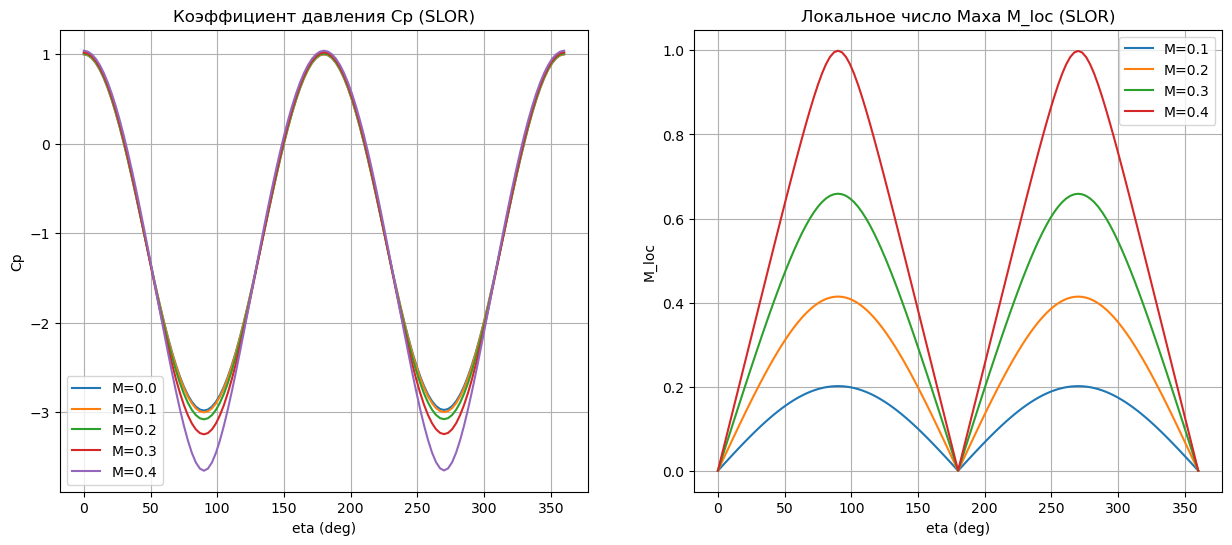

In [20]:
import pandas as pd

machs = [0., 0.1, 0.2, 0.3, 0.4]
results = {}
phi_current = None

for M in machs:
    phi_current = solve_for_mach(M, phi_current)
    results[M] = phi_current

table_data = []
idx_90 = np.argmin(np.abs(eta - np.pi/2))

for M in machs:
    phi = results[M]
    # Характеристики на цилиндре (i=0)
    phi_eta = np.zeros(N_eta + 1)
    # Внутренние узлы по eta
    phi_eta[1:N_eta] = (phi[0, 2:N_eta+1] - phi[0, 0:N_eta-1]) / (2 * h_eta)
    # Границы симметрии: производная по нормали к оси (phi_eta) равна 0
    phi_eta[0] = 0
    phi_eta[N_eta] = 0
    
    q2 = phi_eta**2 # на цилиндре xi=0, phi_xi=0
    q = np.sqrt(q2)
    
    if M == 0:
        cp = 1 - q2
        m_loc = np.zeros_like(q2)
    else:
        rho = (1 + 0.5 * (gamma - 1) * M**2 * (1 - q2))**(1/(gamma-1))
        cp = 2 / (gamma * M**2) * (rho**gamma - 1)
        a2 = 1 + 0.5 * (gamma - 1) * M**2 * (1 - q2)
        m_loc = q * M / np.sqrt(a2)
    
    # Сохранение полной таблицы
    df_m = pd.DataFrame({
        'eta_deg': eta * 180 / np.pi,
        'Cp': cp,
        'M_loc': m_loc
    })
    df_m.to_csv(f'results_slor_M_{M}.csv', index=False)
    
    # Данные для сводки (в точке pi/2)
    table_data.append({
        'M_inf': M, 
        'Cp_pi/2': cp[idx_90], 
        'M_loc_pi/2': m_loc[idx_90]
    })

df_results = pd.DataFrame(table_data)
print("\nРезультаты (SLOR) в точке pi/2:")
print(df_results.to_string(index=False))

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
for M in machs:
    phi = results[M]
    phi_eta = np.zeros(N_eta + 1)
    phi_eta[1:N_eta] = (phi[0, 2:N_eta+1] - phi[0, 0:N_eta-1]) / (2 * h_eta)
    phi_eta[0] = 0; phi_eta[N_eta] = 0
    q2 = phi_eta**2
    if M == 0:
        cp = 1 - q2
    else:
        rho = (1 + 0.5 * (gamma - 1) * M**2 * (1 - q2))**(1/(gamma-1))
        cp = 2 / (gamma * M**2) * (rho**gamma - 1)
    plt.plot(eta*180/np.pi, cp, label=f'M={M}')
plt.title('Коэффициент давления Cp (SLOR)')
plt.xlabel('eta (deg)'); plt.ylabel('Cp'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
for M in machs:
    if M == 0: continue
    phi = results[M]
    phi_eta = np.zeros(N_eta + 1)
    phi_eta[1:N_eta] = (phi[0, 2:N_eta+1] - phi[0, 0:N_eta-1]) / (2 * h_eta)
    phi_eta[0] = 0; phi_eta[N_eta] = 0
    q2 = phi_eta**2
    a2 = 1 + 0.5 * (gamma - 1) * M**2 * (1 - q2)
    m_loc = np.sqrt(q2) * M / np.sqrt(a2)
    plt.plot(eta*180/np.pi, m_loc, label=f'M={M}')
plt.title('Локальное число Маха M_loc (SLOR)')
plt.xlabel('eta (deg)'); plt.ylabel('M_loc'); plt.legend(); plt.grid()
plt.show()
